In [4]:
import tifffile
import spotiflow

img = tifffile.imread("/oak/stanford/projects/kibr/Reorganizing/Projects/James/lipid-droplet-pipeline/data/raw/slides/plin2/04-06.tif")

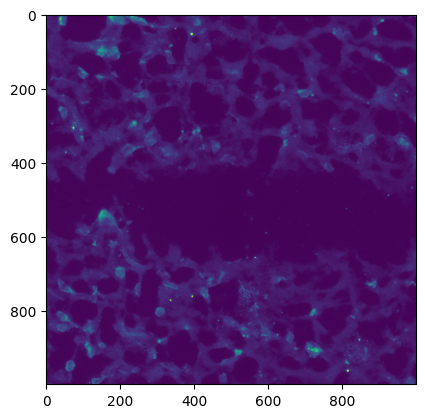

In [21]:
plt.imshow()

In [6]:
from spotiflow.model import Spotiflow
from spotiflow.sample_data import test_image_hybiss_2d

# Load sample image
img = test_image_hybiss_2d()
# Or any other image
# img = tifffile.imread("myimage.tif")

# Load a pretrained model
model = Spotiflow.from_pretrained("general")
# Or load your own trained model from folder
# model = Spotiflow.from_folder("./mymodel")

INFO:spotiflow.model.spotiflow:Loading pretrained model: general
87885382/87885382 [==============================] - 11s 0us/step
INFO:spotiflow.model.spotiflow:Will use device: cpu
INFO:spotiflow.model.spotiflow:Predicting with prob_thresh = [0.49999999999999994], min_distance = 1
INFO:spotiflow.model.spotiflow:Peak detection mode: fast
INFO:spotiflow.model.spotiflow:Image shape (512, 512)
INFO:spotiflow.model.spotiflow:Predicting with (1, 1) tiles
INFO:spotiflow.model.spotiflow:Normalizing...
INFO:spotiflow.model.spotiflow:Padding to shape (512, 512, 1)
INFO:spotiflow.model.spotiflow:Found 212 spots


In [32]:
# Predict
points, details = model.predict(img)

INFO:spotiflow.model.spotiflow:Will use device: cpu
INFO:spotiflow.model.spotiflow:Predicting with prob_thresh = [0.49999999999999994], min_distance = 1
INFO:spotiflow.model.spotiflow:Peak detection mode: fast
INFO:spotiflow.model.spotiflow:Image shape (17009, 17753)
INFO:spotiflow.model.spotiflow:Predicting with (9, 9) tiles
INFO:spotiflow.model.spotiflow:Normalizing...
INFO:spotiflow.model.spotiflow:Padding to shape (17024, 17760, 1)


Predicting tiles:   0%|          | 0/81 [00:00<?, ?it/s]

INFO:spotiflow.model.spotiflow:Found 204379 spots


In [28]:
copy = img.copy()

In [31]:
import pandas as pd
pd.DataFrame(points).to_csv("{folder_key}_coordinates.csv")

,0,1
0,998.969732,137.967217
1,995.068030,117.867705
2,993.708503,147.135446
3,994.139459,48.076634
4,991.631553,864.675698
...,...,...
702,4.904986,998.992266
703,5.009355,923.041367
704,5.560936,54.063377
705,3.997493,81.979537


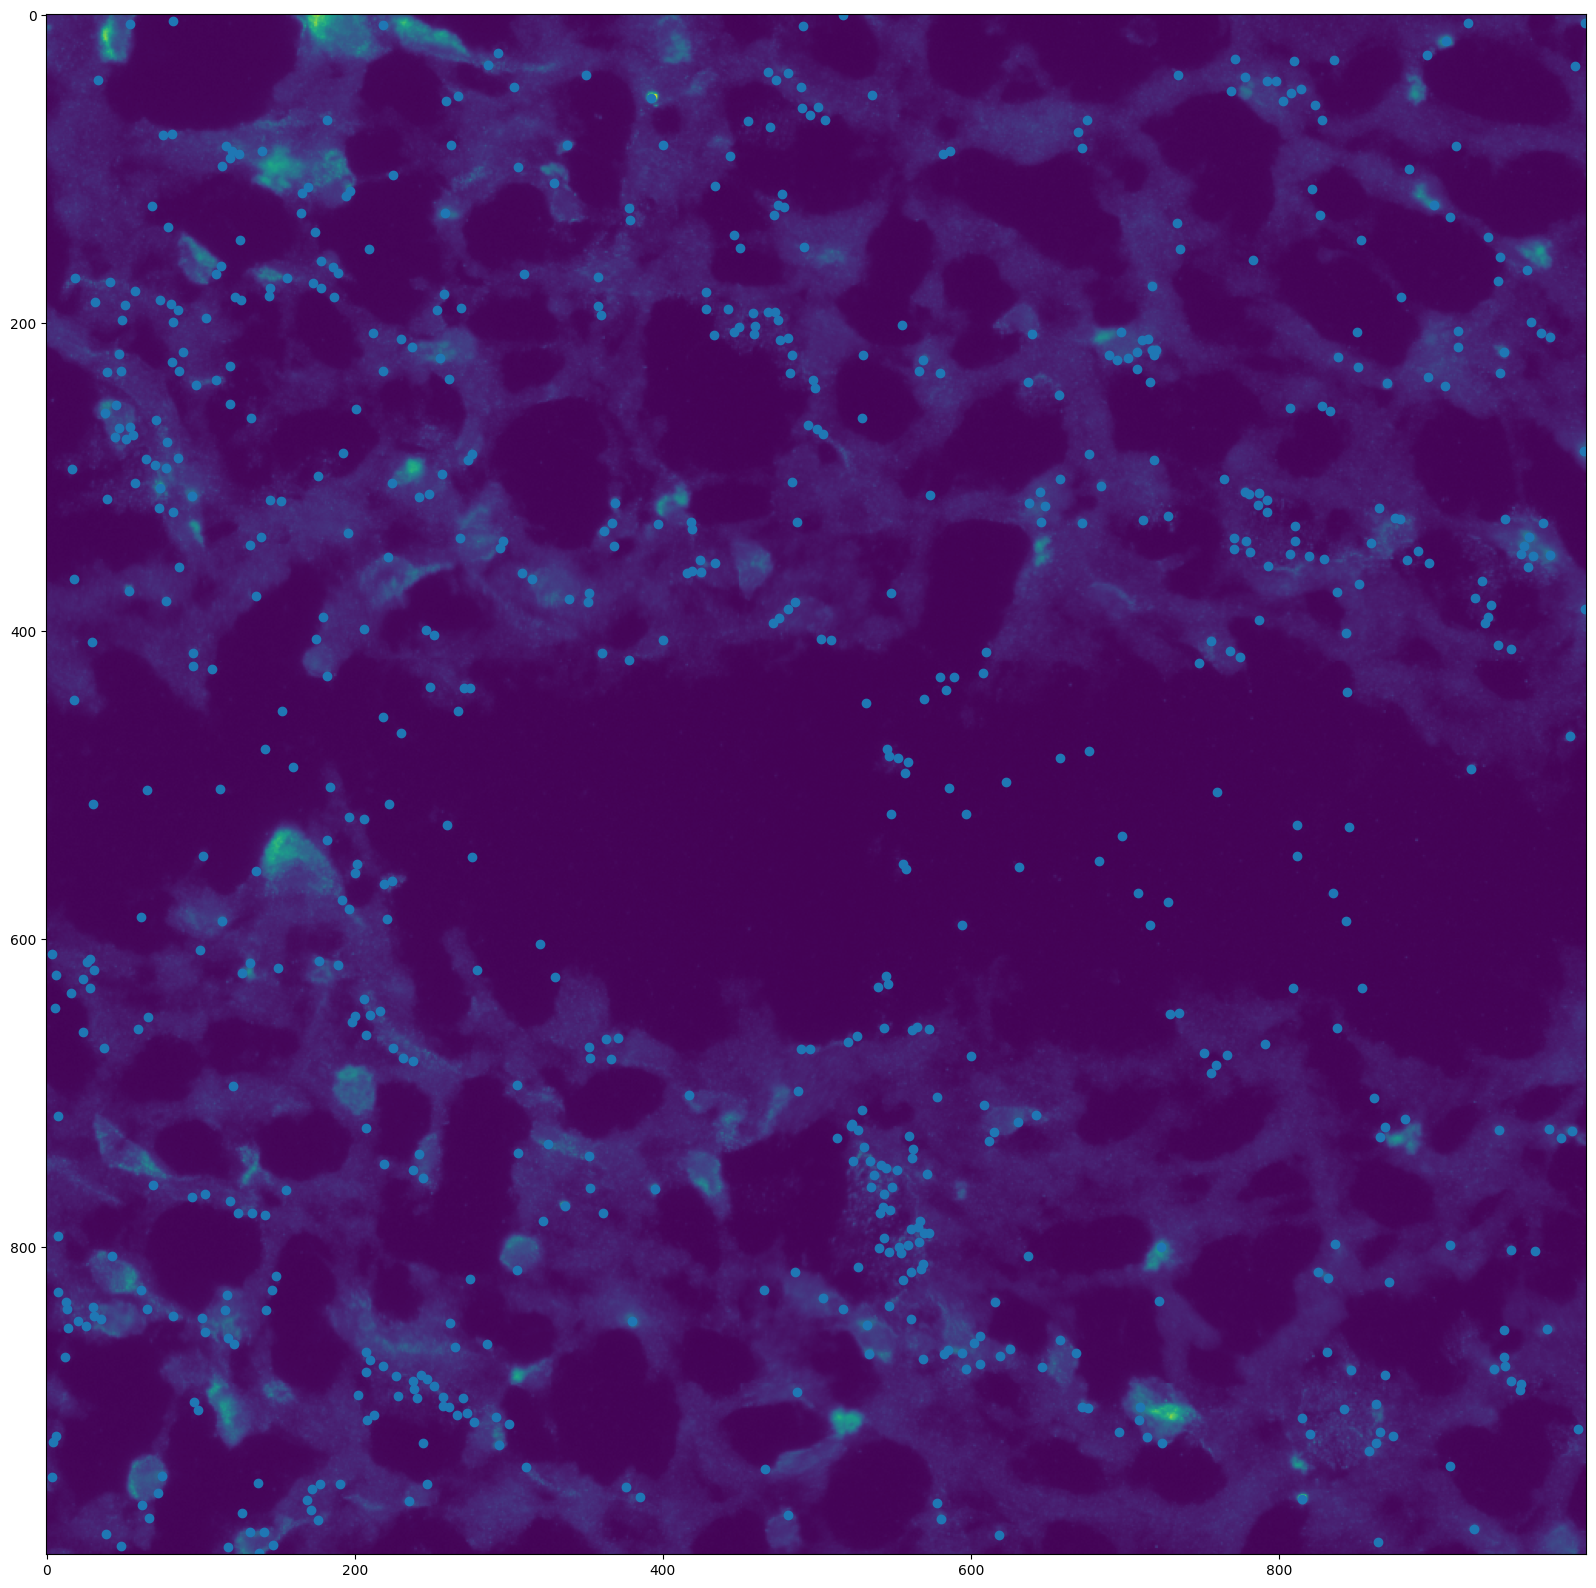

In [27]:
import matplotlib.pyplot as plt
f, ax = plt.subplots(figsize=(20, 20))
ax.imshow(img[10_000:11_000, 10_000:11_000])
plt.scatter(points[:, 1], points[:, 0])

In [15]:
img[28_000:32_000, 38_000:42_000]

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

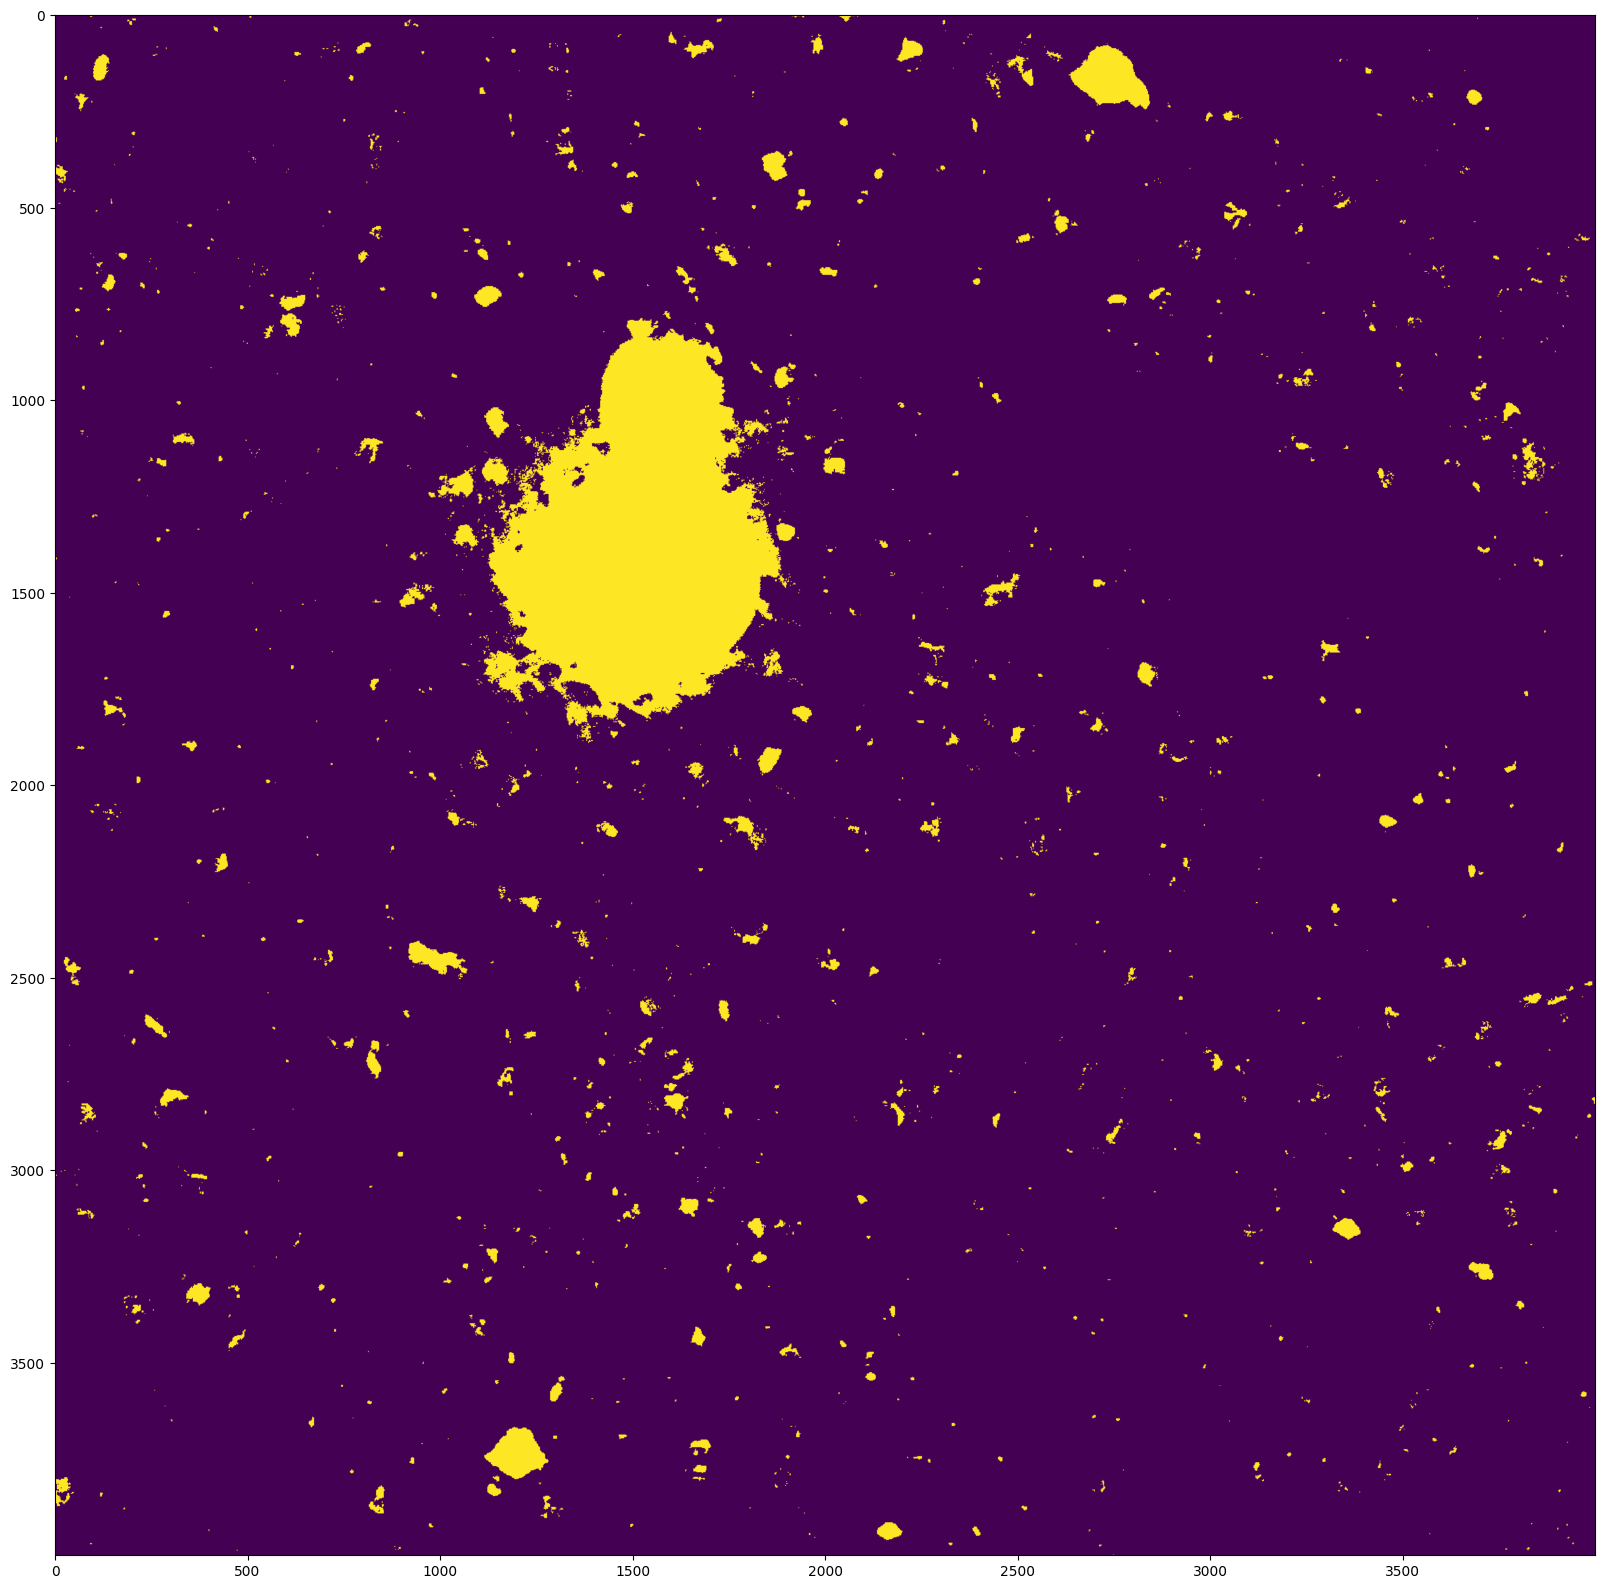

In [12]:
f, ax = plt.subplots(figsize=(20, 20))
ax.imshow(img[28_000:32_000, 38_000:42_000])

In [ ]:
import sys
import pickle
import pathlib
import tifffile
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
from tqdm import tqdm

from PIL import Image, ImageDraw
from shapely.geometry import Polygon

sys.path.append("/oak/stanford/projects/kibr/Reorganizing/Projects/James/lipid-droplet-pipeline/")
from src.image_alignment import *

oil_red_o_image_mapping = {
    "13-69": "Slide_2_13-69_05-27.tif",
    "05-27": "Slide_2_13-69_05-27.tif",
    "14-02": "Slide_1_14-02_18-20.tif",
    "10-46": "Slide_4_10-46_13-54_Slide_Scan.tif",
    "18-20": "Slide_1_14-02_18-20.tif",
    "13-54": "Slide_4_10-46_13-54_Slide_Scan.tif",
    "04-44": "0029269_AD_33_04-44_15-27.tif",
    "15-27": "0029269_AD_33_04-44_15-27.tif",
    "14-20": "0029281_ND_33_18-75_14-20.tif",
    "18-75": "0029281_ND_33_18-75_14-20.tif",
    "04-06": "0029282_AD_44_99-15_04-06.tif",
    "99-15": "0029282_AD_44_99-15_04-06.tif"
}

folder_key = '18-20'

raw_slide_location = pathlib.Path("/oak/stanford/projects/kibr/Reorganizing/Projects/James/lipid-droplet-pipeline/data/raw/slides/")
segmentation_slide_location = pathlib.Path("/oak/stanford/projects/kibr/Reorganizing/Projects/James/lipid-droplet-pipeline/data/processed/segmentation")
segmentation_alignments_location = pathlib.Path("/oak/stanford/projects/kibr/Reorganizing/Projects/James/lipid-droplet-pipeline/data/alignments")

def polygons_to_instance_mask(polygons, image_size):
    """
    Convert a list of polygons to an instance segmentation mask.

    Args:
        polygons: List of polygons, each a list of (x, y) tuples.
        image_size: (width, height) of the output mask.

    Returns:
        A numpy array of shape (height, width) with instance labels.
    """
    width, height = image_size
    mask = Image.new("I", (width, height), 0)  # "I" = 32-bit signed integer pixels
    draw = ImageDraw.Draw(mask)

    for idx, poly_coords in tqdm(enumerate(polygons, start=1)):  # Start instance IDs from 1
        # Draw polygon as filled shape
        draw.polygon(poly_coords, fill=idx)

    return np.array(mask)

boundaries = pd.read_csv(list(pathlib.Path("/oak/stanford/projects/kibr/Reorganizing/Projects/James/lipid-droplet/data/raw/xenium_runs").glob(f"*{folder_key}*"))[0] / "cell_boundaries.csv.gz")

polygons = [
    [(x, y) for x, y in zip(df["vertex_x"]/.2125, df["vertex_y"]/.2125)]
    for cell, df in boundaries.groupby("cell_id")
]

# NOTE: This originally was the code that was used, defines segmentation using random forest masking.
# # plin_path = segmentation_slide_location / "plin2" / f"rf_mask_{folder_key}.pickle"
# # NOTE: 18-20 was especially off, increasing the logits to 0.9 seems to work.
# if folder_key == "18-20":
#     plin_image = pickle.load(open(plin_path, "rb")) >= 0.9
# else:
#     plin_image = pickle.load(open(plin_path, "rb")) >= 0.5

# NOTE: This now uses raw slide cutoffs (anchored off the >50 for 18-20; all others are designated to match the 
# %thresholded plin2 levels, see the checking-segmentation.ipynb file.)
threshold_by_folder = {
    "04-06": 60,
    "14-02": 68,
    "15-27": 64,
    "10-46": 36,
    "18-75": 79,
    "04-44": 53,
    "14-20": 73,
    "18-20": 50,
    "99-15": 69,
    "05-27": 30,
    "13-69": 49,
    "13-54": 25,
}

plin_path = raw_slide_location / "plin2" / f"{folder_key}.tif"
plin_image = (tifffile.imread(plin_path) >= threshold_by_folder[folder_key])

oil_red_o_path = segmentation_slide_location / "oil-red-o" / oil_red_o_image_mapping[folder_key]
oil_red_o_image = tifffile.imread(oil_red_o_path) >= 0.5 

# Finds the size of the slide, and returns the minimal bounding box plus a large berth for safety.
cells = pd.read_csv(list(pathlib.Path("/oak/stanford/projects/kibr/Reorganizing/Projects/James/lipid-droplet/data/raw/xenium_runs").glob(f"*{folder_key}*"))[0] / "cells.csv.gz")
x_max, y_max = cells[["x_centroid", "y_centroid"]].max().tolist()
output_shape = (round(y_max / 0.2125), round(x_max / 0.2125))

# Generates generous segmentation masks for warping.
print(f"Warping {folder_key} - IF")
plin_image = apply_transformation_matrix(
    plin_image,
    segmentation_alignments_location / "plin2" / f"{folder_key}.csv",
    output_shape
) > 0
instance_segmentation = polygons_to_instance_mask(polygons, plin_image.shape[::-1])
plin_image = instance_segmentation * plin_image
tifffile.imwrite(f"/oak/stanford/projects/kibr/Reorganizing/Projects/James/lipid-droplet-pipeline/data/processed/warped_segmentation/plin2/{folder_key}.tif", instance_segmentation * (plin_image).astype(int))

print(f"Warping {folder_key} - Oil Red O")
oil_red_o_image = apply_transformation_matrix(
    oil_red_o_image, 
    segmentation_alignments_location / "oil-red-o" / f"{folder_key}.csv", 
    output_shape
) > 0
instance_segmentation = polygons_to_instance_mask(polygons, oil_red_o_image.shape[::-1])
oil_red_o_image = instance_segmentation * oil_red_o_image
tifffile.imwrite(f"/oak/stanford/projects/kibr/Reorganizing/Projects/James/lipid-droplet-pipeline/data/processed/warped_segmentation/oil_red_o/{folder_key}.tif", instance_segmentation * (oil_red_o_image).astype(int))

# Convert to measurements
print(f"Measurement of {folder_key} PLIN2")
plin_measurements = generate_measurements((instance_segmentation * plin_image))
plin_measurements.to_csv(f"/oak/stanford/projects/kibr/Reorganizing/Projects/James/lipid-droplet-pipeline/data/processed/locations/plin2/{folder_key}.csv")

print(f"Measurement of {folder_key} Oil Red O")
oil_red_o_measurements = generate_measurements(oil_red_o_image)
oil_red_o_measurements.to_csv(f"/oak/stanford/projects/kibr/Reorganizing/Projects/James/lipid-droplet-pipeline/data/processed/locations/oil-red-o/{folder_key}.csv")

# Get the masks
print(f"Mask of {folder_key} LDs")
lipid_droplet = ((oil_red_o_image > 0) & (plin_image>0))
instance_segmentation = polygons_to_instance_mask(polygons, lipid_droplet.shape[::-1]).astype(int)
lipid_droplet = instance_segmentation * lipid_droplet

# Lipid Droplet Measurements
print(f"Measurements of {folder_key} LDs")
lipid_droplet_measurements = generate_measurements(lipid_droplet)
lipid_droplet_measurements.to_csv(f"/oak/stanford/projects/kibr/Reorganizing/Projects/James/lipid-droplet-pipeline/data/processed/locations/lipid-droplet/{folder_key}.csv")

print(f"Writing {folder_key}")
tifffile.imwrite(f"/oak/stanford/projects/kibr/Reorganizing/Projects/James/lipid-droplet-pipeline/data/processed/segmentation/lipid-droplet/{folder_key}.tif", instance_segmentation * (lipid_droplet).astype(int))